In [3]:
from glob import glob
from pandas import DataFrame
from IPython.display import display
import func_preparation as dbf
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style('whitegrid')


# Settings

In [ ]:
path = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/exploration/'

In [5]:
hindcast_start = 1960
hindcast_end = 2026

In [6]:
return_periods = [10, 25, 50, 100, 200]
plot_period_evolution = ['10-year', '50-year', '100-year']

# Import Data

In [7]:
ls_files = [file for file in glob(path + '*.nc')]
ls_files

['../input/Annual_max_DCPP_20260112/Annual_max_MIROC6.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_MPI-ESM1-2-HR.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_HadGEM3-GC31-MM.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_MRI-ESM2-0.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_BCC-CSM2-MR.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_CMCC-CM2-SR5.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_CanESM5.nc',
 '../input/Annual_max_DCPP_20260112/Annual_max_NorCPM1.nc']

In [8]:
dic_data_per_model = dbf.import_all_models(ls_files)

# Prepare Data 
Bias Correction, Validity Flag Extraction, Rearrangement per Location

In [9]:
dic_data_per_model, combined, notes_overview = dbf.prepare_combined_data(ls_files, dic_data_per_model)

In [10]:
dic_data_per_location = dbf.extract_location_data(combined, hindcast_start, hindcast_end)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.18859630964927226s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.16208600997924805s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done 188 tasks      | elapsed:    9.1s
[Parallel(n_jobs=-1)]: Done 248 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 316 tasks      | elaps

# Plot Map of Missing Data

In [11]:
n_obs_per_location = dbf.get_number_of_observations_per_site(dic_data_per_location)
n_obs_per_location

,site_id,lat,lon,n_obs
0,0,27.731363,-18.157674,8248
1,1,27.792446,-18.156254,8248
2,2,27.696402,-18.108071,8248
3,3,27.759870,-18.107191,8248
4,4,28.771595,-18.064526,7182
...,...,...,...,...
9584,9584,34.568596,35.991938,7182
9585,9585,36.498109,36.000442,988
9586,9586,36.535215,36.038422,988
9587,9587,36.559169,36.095013,988


In [30]:
df_missing_location, df_valid, fig_map = dbf.create_summary_location_w_missing_data(
    dic_data_per_model=dic_data_per_model, combined=combined, n_obs_per_location=n_obs_per_location, 
    dir_export=None
    )

In [31]:
display(fig_map)

{
  "initialViewState": {
    "latitude": 47.481158821977395,
    "longitude": 1.818047448020954,
    "zoom": 4
  },
  "layers": [
    {
      "@@type": "ScatterplotLayer",
      "data": [
        {
          "info": "Observations: 8248",
          "lat": 27.731362916530976,
          "lon": -18.15767355838487,
          "n_obs": 8248
        },
        {
          "info": "Observations: 8248",
          "lat": 27.79244626145107,
          "lon": -18.156254160356895,
          "n_obs": 8248
        },
        {
          "info": "Observations: 8248",
          "lat": 27.69640206266119,
          "lon": -18.10807063569109,
          "n_obs": 8248
        },
        {
          "info": "Observations: 8248",
          "lat": 27.759869810153713,
          "lon": -18.107191473499554,
          "n_obs": 8248
        },
        {
          "info": "Observations: 7182",
          "lat": 28.771594783871667,
          "lon": -18.06452551334023,
          "n_obs": 7182
        },
        {
          "info": "Observations: 8248",
          "lat": 27.766617170766736,
          "lon": -18.047638212715224,
          "n_obs": 8248
        },
        {
          "info": "Observations: 8248",
          "lat": 27.683705744391478,
          "lon": -18.040604436421543,
          "n_obs": 8248
        },
        {
          "info": "Observations: 8248",
          "lat": 27.62787712645259,
          "lon": -18.013294956881424,
          "n_obs": 8248
        },
        {
          "info": "Observations: 7182",
          "lat": 28.756342235113834,
          "lon": -18.007870339772143,
          "n_obs": 7182
        },
        {
          "info": "Observations: 8248",
          "lat": 27.798693127506567,
          "lon": -18.00272598910649,
          "n_obs": 8248
        },
        {
          "info": "Observations: 7182",
          "lat": 28.80994860509667,
          "lon": -17.99348000843645,
          "n_obs": 7182
        },
        {
          "info": "Observations: 7182",
          "lat": 28.709579556493903,
          "lon": -17.986909658313678,
          "n_obs": 7182
        },
        {
          "info": "Observations: 8248",
          "lat": 27.681548055058173,
          "lon": -17.963519025001897,
          "n_obs": 8248
        },
        {
          "info": "Observations: 7182",
          "lat": 28.852069490743066,
          "lon": -17.947465131103222,
          "n_obs": 7182
        },
        {
          "info": "Observations: 8248",
          "lat": 27.845571991578932,
          "lon": -17.9461407523318,
          "n_obs": 8248
        },
        {
          "info": "Observations: 7182",
          "lat": 28.64030379752477,
          "lon": -17.943257443809173,
          "n_obs": 7182
        },
        {
          "info": "Observations: 8248",
          "lat": 27.721889786629486,
          "lon": -17.933721626990856,
          "n_obs": 8248
        },
        {
          "info": "Observations: 7182",
          "lat": 28.57600456101011,
          "lon": -17.906151764495974,
          "n_obs": 7182
        },
        {
          "info": "Observations: 8248",
          "lat": 27.77356461555206,
          "lon": -17.902684528224572,
          "n_obs": 8248
        },
        {
          "info": "Observations: 8248",
          "lat": 27.837758279635434,
          "lon": -17.894199792077373,
          "n_obs": 8248
        },
        {
          "info": "Observations: 7182",
          "lat": 28.85139664714212,
          "lon": -17.88479085346704,
          "n_obs": 7182
        },
        {
          "info": "Observations: 7182",
          "lat": 28.5093820825007,
          "lon": -17.876544425206927,
          "n_obs": 7182
        },
        {
          "info": "Observations: 7182",
          "lat": 28.454213401631954,
          "lon": -17.84548251594003,
          "n_obs": 7182
        },
        {
          "info": "Observations: 7182",
          "lat": 28.841591400757235,
          "lon": -17.828473827742116,
          "n_obs": 7182
 

# Validation Check

In [14]:
def get_vadility_of_location(dic_ds, location):
    ls_vadility = []
    for ds in dic_ds:    
        dist = (ds["lon"] - location.lon)**2 + (ds["lat"] - location.lat)**2
        nearest_site_index = dist.argmin(dim="sites")

        ds_sel = ds.isel(sites=nearest_site_index)
        ls_vadility.append(ds_sel.model_valid.values)
    return ls_vadility

In [15]:
dic_ds = [dic_data_per_model[model_label]['raw data'] for model_label in dic_data_per_model.keys()]

In [16]:
dic_vadility_locations = dict()
for siteID in df_missing_location.index:
    location = df_missing_location.loc[siteID]

    ls_vadility = get_vadility_of_location(dic_ds=dic_ds, location=location)
    dic_vadility_locations[siteID] = ls_vadility

In [17]:
data_to_plot = DataFrame.from_dict(dic_vadility_locations).astype(int)
data_to_plot.index.name = 'model_label'
data_to_plot.index = dic_data_per_model.keys()

data_to_plot.T.index.name = 'siteID'
data_to_plot.T.sum(axis=1)

siteID
165     0
797     0
1300    0
317     0
1389    0
       ..
1015    0
38      0
453     0
548     0
273     0
Length: 1433, dtype: int64

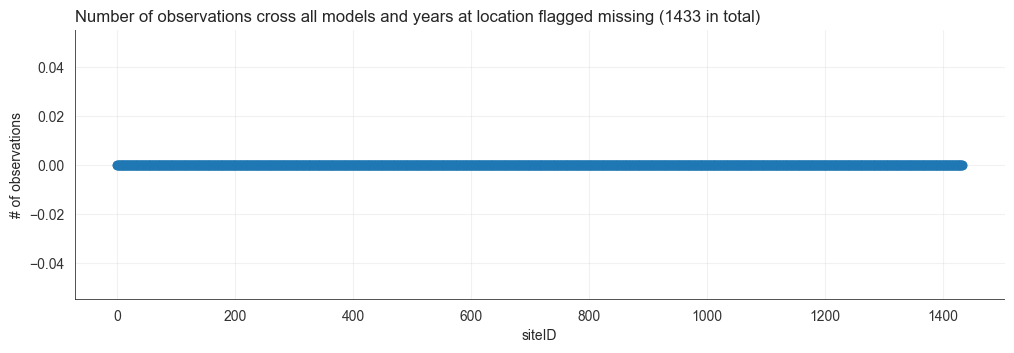

In [ ]:
%matplotlib inline
axes_color: str = '#333333'

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(data_to_plot.T.sum(axis=1), marker='o', lw=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.axhline(y=ax.get_ylim()[0], color=axes_color, linewidth=1.2, zorder=10)
ax.axvline(x=ax.get_xlim()[0], color=axes_color, linewidth=1.2, zorder=10)

ax.tick_params(axis='x', colors=axes_color)
ax.tick_params(axis='y', colors=axes_color)

ax.grid(True, alpha=0.3, color='lightgrey')
ax.set_xlabel('siteID')
ax.set_ylabel('# of observations')
ax.set_title(
    'Number of observations cross all models and years at location flagged missing '
    f'({len(df_missing_location.index)} in total)', 
    loc='left'
    )

plt.show()

#fig.savefig(path_export+'ValidationCheck_missingData_forLocations.png', dpi=300)